## 0. Load data

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

In [2]:
pfas = pd.read_csv('no_sn_torsions_202.csv')
pfas

,Molecule,SMILES,Torsions C-C-C-C,Torsions C-C-C-F,Torsions F-C-C-C,Torsions F-C-C-F,Torsions H-O-C-F,Torsions H-O-C-C,Torsions O-C-C-C,Torsions O-C-C-F,...,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H,a0,a1,a2,a3,a4,S_300K,H_f_0K
0,butene,FC(F)=C(F)C(F)(F)C(F)(F)F,1,5,1,8,0,0,0,0,...,0,0,0,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11,104.398839,-371.81
1,butene_OH,OC(F)(F)[C](F)C(F)(F)C(F)(F)F,1,5,3,10,2,1,1,1,...,0,0,0,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11,44.901000,-419.97
2,pentene,FC(F)=C(F)C(F)(F)C(F)(F)C(F)(F)F,2,7,3,12,0,0,0,0,...,0,0,0,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11,119.440000,-470.07
3,hexene,FC(F)=C(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,3,8,6,16,0,0,0,0,...,0,0,0,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11,134.200000,-567.50
4,heptene,FC(F)=C(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,4,10,8,20,0,0,0,0,...,0,0,0,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11,147.340000,-665.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,pfpeoh,OC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,2,9,4,18,0,0,0,0,...,0,0,0,9.9632,0.21492,-0.000212,9.730000e-08,-1.680000e-11,127.540000,0.00
122,pfpncof,O=C(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,2,8,4,16,0,0,0,0,...,0,0,0,10.4950,0.18766,-0.000184,8.370000e-08,-1.440000e-11,123.370000,0.00
123,pfpra,O=C(O)C(F)(F)C(F)(F)F,0,0,3,6,0,0,0,0,...,0,0,0,5.7283,0.12156,-0.000117,5.280000e-08,-9.030000e-12,96.243000,0.00
124,pfprcof,O=C(F)C(F)(F)C(F)(F)F,0,1,3,8,0,0,0,0,...,0,0,0,7.0146,0.11110,-0.000108,4.880000e-08,-8.340000e-12,95.561000,0.00


## 1. Data preparation before fitting models

In [41]:
X = pfas[pfas.columns[2:34]]
X

,Torsions C-C-C-C,Torsions C-C-C-F,Torsions F-C-C-C,Torsions F-C-C-F,Torsions H-O-C-F,Torsions H-O-C-C,Torsions O-C-C-C,Torsions O-C-C-F,Torsions F-C-C-O,Torsions C-C-C-O,...,Torsions C-O-C-H,Torsions C-O-C-F,Torsions C-O-C-C,Torsions H-C-C-F,Torsions O-C-C-O,Torsions C-O-C-O,Torsions O-C-O-C,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H
0,1,5,1,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,5,3,10,2,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,7,3,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,8,6,16,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,10,8,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2,9,4,18,0,0,0,0,2,1,...,0,0,0,0,0,0,0,0,0,0
122,2,8,4,16,0,0,0,0,2,1,...,0,0,0,0,0,0,0,0,0,0
123,0,0,3,6,0,0,0,0,4,2,...,0,0,0,0,0,0,0,0,0,0
124,0,1,3,8,0,0,0,0,2,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
Y = pfas[pfas.columns[34:39]]
Y

,a0,a1,a2,a3,a4
0,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11
1,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11
2,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11
3,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11
4,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11
...,...,...,...,...,...
121,9.9632,0.21492,-0.000212,9.730000e-08,-1.680000e-11
122,10.4950,0.18766,-0.000184,8.370000e-08,-1.440000e-11
123,5.7283,0.12156,-0.000117,5.280000e-08,-9.030000e-12
124,7.0146,0.11110,-0.000108,4.880000e-08,-8.340000e-12


In [6]:
Y1 = pfas[pfas.columns[35:39]]
Y1

,a1,a2,a3,a4
0,0.13653,-0.000133,6.050000e-08,-1.040000e-11
1,0.16092,-0.000159,7.290000e-08,-1.260000e-11
2,0.17448,-0.000171,7.770000e-08,-1.330000e-11
3,0.21282,-0.000209,9.510000e-08,-1.630000e-11
4,0.25169,-0.000248,1.130000e-07,-1.940000e-11
...,...,...,...,...
121,0.21492,-0.000212,9.730000e-08,-1.680000e-11
122,0.18766,-0.000184,8.370000e-08,-1.440000e-11
123,0.12156,-0.000117,5.280000e-08,-9.030000e-12
124,0.11110,-0.000108,4.880000e-08,-8.340000e-12


In [7]:
XY = pd.concat([X,Y], axis = 1)
XY

,Torsions C-C-C-C,Torsions C-C-C-F,Torsions F-C-C-C,Torsions F-C-C-F,Torsions H-O-C-F,Torsions H-O-C-C,Torsions O-C-C-C,Torsions O-C-C-F,Torsions F-C-C-O,Torsions C-C-C-O,...,Torsions C-O-C-O,Torsions O-C-O-C,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H,a0,a1,a2,a3,a4
0,1,5,1,8,0,0,0,0,0,0,...,0,0,0,0,0,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11
1,1,5,3,10,2,1,1,1,0,0,...,0,0,0,0,0,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11
2,2,7,3,12,0,0,0,0,0,0,...,0,0,0,0,0,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11
3,3,8,6,16,0,0,0,0,0,0,...,0,0,0,0,0,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11
4,4,10,8,20,0,0,0,0,0,0,...,0,0,0,0,0,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2,9,4,18,0,0,0,0,2,1,...,0,0,0,0,0,9.9632,0.21492,-0.000212,9.730000e-08,-1.680000e-11
122,2,8,4,16,0,0,0,0,2,1,...,0,0,0,0,0,10.4950,0.18766,-0.000184,8.370000e-08,-1.440000e-11
123,0,0,3,6,0,0,0,0,4,2,...,0,0,0,0,0,5.7283,0.12156,-0.000117,5.280000e-08,-9.030000e-12
124,0,1,3,8,0,0,0,0,2,1,...,0,0,0,0,0,7.0146,0.11110,-0.000108,4.880000e-08,-8.340000e-12


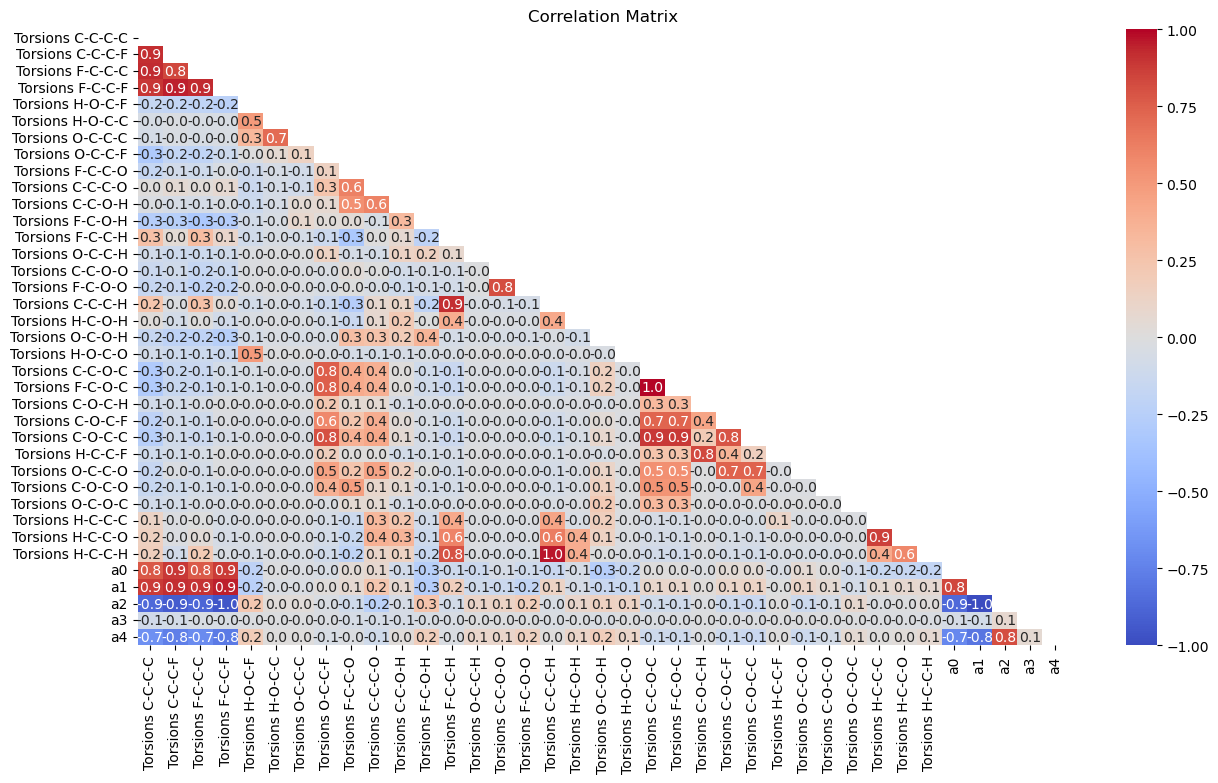

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
XY_corr = XY.corr(method='pearson')
plt.figure(figsize=(15,8))
mask = np.triu(np.ones_like(XY_corr, dtype=bool))
sns.heatmap(XY_corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.1f')
plt.title('Correlation Matrix')
plt.show()

In [39]:
XY_corr[XY_corr.columns[32:37]]

,a0,a1,a2,a3,a4
Torsions C-C-C-C,0.777830,0.881798,-0.864450,-0.093280,-0.675333
Torsions C-C-C-F,0.888550,0.918535,-0.926516,-0.077623,-0.761433
Torsions F-C-C-C,0.765775,0.899090,-0.882115,-0.046193,-0.698268
Torsions F-C-C-F,0.875623,0.949192,-0.954105,-0.042773,-0.785127
Torsions H-O-C-F,-0.217866,-0.241982,0.234064,-0.016196,0.191284
Torsions H-O-C-C,-0.011577,-0.032081,0.027106,-0.008000,0.014061
Torsions O-C-C-C,-0.027291,-0.034000,0.027043,-0.011359,0.009624
Torsions O-C-C-F,-0.047315,0.021762,-0.031426,-0.026441,-0.051517
Torsions F-C-C-O,0.043362,0.069564,-0.096112,-0.056120,-0.022357
Torsions C-C-C-O,0.077648,0.236300,-0.227700,-0.063193,-0.097759


High correlation with each other (>=0.9)
- C-C-C-F and C-C-C-C
- F-C-C-C and C-C-C-C
- F-C-C-F and C-C-C-F
- F-C-C-F and F-C-C-C
- Why are F-C-C-C and C-C-C-F torsions 2 different things and only correlate with each other 0.841904?
--> (C-C-C-C and/or F-C-C-F) correlate to (F-C-C-C and C-C-C-F) --> Drop C-C-C-C and F-C-C-F.
- C-C-C-H and F-C-C-H
- C-C-C-H and H-C-C-H
--> C-C-C-H correlates to (F-C-C-H and H-C-C-H), but F-C-C-H and H-C-C-H don't strongly correlates to each other.
  --> Drop C-C-C-H.
- F-C-O-C and C-C-O-C
- C-O-C-C and F-C-O-C
--> Drop F-C-O-C.
Low correlation with all targets (<= 0.1): 14 descriptors
H-O-C-C, O-C-C-C, O-C-C-F, F-C-C-O, C-C-O-H, C-C-C-H, C-C-O-C, C-O-C-H, H-C-C-F, C-O-C-O, O-C-O-C

In [42]:
X.drop(['Torsions H-O-C-C', 'Torsions O-C-C-C', 'Torsions O-C-C-F', 'Torsions F-C-C-O', 'Torsions C-C-O-H', 'Torsions C-C-O-C', 'Torsions C-O-C-H', 'Torsions H-C-C-F', 'Torsions C-O-C-O', 'Torsions O-C-O-C'], axis=1, inplace=True)
X

/tmp/ipykernel_3386114/1556580973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(['Torsions H-O-C-C', 'Torsions O-C-C-C', 'Torsions O-C-C-F', 'Torsions F-C-C-O', 'Torsions C-C-O-H', 'Torsions C-C-O-C', 'Torsions C-O-C-H', 'Torsions H-C-C-F', 'Torsions C-O-C-O', 'Torsions O-C-O-C'], axis=1, inplace=True)


,Torsions C-C-C-C,Torsions C-C-C-F,Torsions F-C-C-C,Torsions F-C-C-F,Torsions H-O-C-F,Torsions C-C-C-O,Torsions F-C-O-H,Torsions F-C-C-H,Torsions O-C-C-H,Torsions C-C-O-O,...,Torsions H-C-O-H,Torsions O-C-O-H,Torsions H-O-C-O,Torsions F-C-O-C,Torsions C-O-C-F,Torsions C-O-C-C,Torsions O-C-C-O,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H
0,1,5,1,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,5,3,10,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,7,3,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,8,6,16,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,10,8,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2,9,4,18,0,1,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
122,2,8,4,16,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
123,0,0,3,6,0,2,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
124,0,1,3,8,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
X.drop(['Torsions C-C-C-C', 'Torsions F-C-C-F', 'Torsions C-C-C-H'], axis=1, inplace=True)
X

/tmp/ipykernel_3386114/2300464621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(['Torsions C-C-C-C', 'Torsions F-C-C-F', 'Torsions C-C-C-H'], axis=1, inplace=True)


,Torsions C-C-C-F,Torsions F-C-C-C,Torsions H-O-C-F,Torsions C-C-C-O,Torsions F-C-O-H,Torsions F-C-C-H,Torsions O-C-C-H,Torsions C-C-O-O,Torsions F-C-O-O,Torsions H-C-O-H,Torsions O-C-O-H,Torsions H-O-C-O,Torsions F-C-O-C,Torsions C-O-C-F,Torsions C-O-C-C,Torsions O-C-C-O,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H
0,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,5,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,7,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,8,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,10,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,9,4,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
122,8,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
123,0,3,0,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
124,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Fitting models

In [45]:
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, MultiTaskElasticNet, MultiTaskLasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn_evaluation import plot
from sklearn.inspection import permutation_importance

In [46]:
# Fit model and compute regression scores (R2), including CV:
def report_regression_scores(model, X_train, y_train, X_test, y_test, X, y, cv):
    # fit & predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # --- holdout (train/test split) metrics ---
    train_r2   = metrics.r2_score(y_train, y_train_pred)
    test_r2    = metrics.r2_score(y_test, y_pred)
    train_MAE = metrics.mean_absolute_error(y_train, y_train_pred)
    test_MAE = metrics.mean_absolute_error(y_test, y_pred)

    # --- cross-validation metrics ---
    scores = cross_validate(
        model, X, y,
        cv=cv,                    
        return_train_score=True,
        scoring='r2',
    )
    scores_table = pd.DataFrame(scores)

    train_cv_scores = np.round(scores_table["train_score"].values, 3)
    test_cv_scores  = np.round(scores_table["test_score"].values, 3)

    # Build & return a summary table
    summary_df = pd.DataFrame({
        "Train R2":   [round(train_r2,3)],
        "Test R2":    [round(test_r2,3)],
        "Train MAE":    [round(train_MAE,3)],
        "Test MAE":    [round(test_MAE,3)],
        "Train CV Scores": [train_cv_scores],
        "Test CV Scores": [test_cv_scores],
    }, index=[model.__class__.__name__])

    return summary_df

In [47]:
import math
# Plot permutation feature importance
def plot_permutation_importance(models, X_train, y_train, X_test, y_test, feature_names, cols, n_features, n_repeats=30, random_state=15):
    # create subplots
    n = len(models)
    rows = math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    if n == 1:
        axes = [axes]    
    axes = axes.flatten()

    # fit model and plot permutation feature importance 
    for ax, model in zip(axes, models):
        model.fit(X_train, y_train)
        r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=random_state)
        idxs = r.importances_mean.argsort()[::-1]

        ax.barh(range(len(idxs)), r.importances_mean[idxs], xerr=r.importances_std[idxs], align='center')
        ax.set_yticks(range(len(idxs)))
        ax.set_yticklabels([feature_names[i] for i in idxs])
        ax.invert_yaxis()
        ax.set_title(f"{model.__class__.__name__}")
        ax.set_xlabel("Permutation Importance")

    for empty_ax in axes[len(models):]:
        empty_ax.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"PFI_{n_features}features.png",        
            dpi=300,
            bbox_inches='tight')
    plt.show()

In [48]:
# list out all the models I wanna try
models = [LinearRegression(),
          Ridge(alpha=0.5, random_state=42),
          Lasso(alpha=0.01, max_iter=10000, random_state=42),
          MultiTaskLasso(alpha=0.01, max_iter=10000, random_state=42),
          ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42),
          MultiTaskElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42),
          RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1),
          ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1),
          DecisionTreeRegressor(random_state=42),
          KNeighborsRegressor(n_neighbors=3, weights="distance", metric="minkowski", p=1),
          MLPRegressor(
              hidden_layer_sizes=(32,16),
              activation="relu",
              solver="adam",
              alpha=1e-3,
              learning_rate_init=1e-3,
              max_iter=5000,
              early_stopping=True,
              validation_fraction=0.2,
              n_iter_no_change=30,
              random_state=1)]

In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
X_MMS = MinMaxScaler().fit_transform(X)
Y_SS = StandardScaler().fit_transform(Y)
X_train, X_test, y_train, y_test = train_test_split(X_MMS, Y_SS, test_size=0.25, random_state=42)
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MMS, Y_SS, 4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
all_summaries.round(3)
display(all_summaries)

,Train R2,Test R2,Train MAE,Test MAE,Train CV Scores,Test CV Scores
LinearRegression,0.784,-4.097318e+12,0.159,0.229,"[0.889, 0.703, 0.767, 0.704]","[0.714, -2330357340684.644, -2318437391749.02,..."
Ridge,0.776,-2.032753e+12,0.166,0.229,"[0.883, 0.694, 0.752, 0.697]","[0.712, -1181288789869.117, -1382573631973.116..."
Lasso,0.763,-8.219084e+11,0.176,0.240,"[0.679, 0.682, 0.737, 0.681]","[0.73, -858428989924.427, -459120450816.068, -..."
MultiTaskLasso,0.773,-1.591516e+12,0.167,0.229,"[0.879, 0.691, 0.749, 0.692]","[0.728, -1437337747161.278, -912468716878.875,..."
ElasticNet,0.767,-1.189889e+12,0.177,0.239,"[0.681, 0.683, 0.741, 0.686]","[0.721, -1023690765575.563, -769382762182.914,..."
MultiTaskElasticNet,0.771,-1.633214e+12,0.172,0.234,"[0.879, 0.689, 0.746, 0.691]","[0.72, -1268923342624.047, -1010897231089.532,..."
RandomForestRegressor,0.840,-1.879694e+13,0.160,0.277,"[0.91, 0.779, 0.819, 0.788]","[0.682, -4901856783658.752, -12299309054728.12..."
ExtraTreesRegressor,0.992,-4.297161e+13,0.028,0.242,"[0.945, 0.942, 0.97, 0.981]","[0.683, -8158264770.243, -32846250793767.97, 0..."
DecisionTreeRegressor,0.992,-1.242874e+14,0.028,0.297,"[0.945, 0.942, 0.97, 0.981]","[0.656, 0.699, -90958623857574.17, 0.205]"
KNeighborsRegressor,0.992,-1.934076e+13,0.028,0.258,"[0.945, 0.942, 0.97, 0.981]","[0.594, 0.575, -14154366362168.025, -0.294]"


In [50]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
X_MMS = MinMaxScaler().fit_transform(X)
Y1_SS = StandardScaler().fit_transform(Y1)
X_train, X_test, y_train, y_test = train_test_split(X_MMS, Y1_SS, test_size=0.25, random_state=42)
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MMS, Y1_SS, 4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
all_summaries.round(3)
display(all_summaries)

,Train R2,Test R2,Train MAE,Test MAE,Train CV Scores,Test CV Scores
LinearRegression,0.748,-5.121648e+12,0.151,0.212,"[0.896, 0.649, 0.747, 0.661]","[0.674, -2912946675855.961, -2898046739686.468..."
Ridge,0.740,-2.540941e+12,0.156,0.218,"[0.891, 0.641, 0.735, 0.654]","[0.677, -1476610987336.555, -1728217039966.618..."
Lasso,0.728,-1.027385e+12,0.160,0.217,"[0.639, 0.628, 0.722, 0.639]","[0.691, -1073036237405.702, -573900563520.308,..."
MultiTaskLasso,0.736,-1.828818e+12,0.152,0.213,"[0.886, 0.637, 0.732, 0.647]","[0.692, -1651553967036.034, -1035731296112.927..."
ElasticNet,0.731,-1.487361e+12,0.164,0.227,"[0.64, 0.629, 0.724, 0.642]","[0.687, -1279613456969.624, -961728452728.864,..."
MultiTaskElasticNet,0.735,-1.957727e+12,0.161,0.225,"[0.886, 0.635, 0.729, 0.647]","[0.687, -1571662790990.038, -1204984774635.962..."
RandomForestRegressor,0.822,-2.185132e+13,0.144,0.248,"[0.919, 0.747, 0.817, 0.767]","[0.662, -5895124675959.837, -14838674064761.14..."
ExtraTreesRegressor,0.995,-3.791324e+13,0.021,0.189,"[0.948, 0.935, 0.992, 0.994]","[0.692, -40791371910.988, -35403370648383.836,..."
DecisionTreeRegressor,0.995,-1.553592e+14,0.021,0.248,"[0.948, 0.935, 0.992, 0.994]","[0.666, 0.787, -113698279821967.9, -0.085]"
KNeighborsRegressor,0.995,-2.417595e+13,0.021,0.226,"[0.948, 0.935, 0.992, 0.994]","[0.597, 0.614, -17692957952710.188, -0.416]"
